In [1]:
##### notebook for running background processors and making plots

import awkward as ak
import numpy as np
import pickle
import hist
import coffea
from python.plugins import *
%matplotlib inline

# from hist import intervals
import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib as mpl
plt.style.use([hep.style.CMS, hep.style.firamath])
hep.style.use("CMS")

In [2]:
from python.plotting import plotDataMC, plotDataMCwErrors
%load_ext autoreload

%autoreload 2

In [3]:
#### Booleans for deciding which plots to make live in this cell
dijet = True


In [7]:
if dijet:
    channel = "dijet"
    # fname_z = "coffeaOutput/dijet/Zjets_dijetSel__fixSDmass_MG_2018.pkl"
    # fname_w = "coffeaOutput/dijet/Wjets_dijetSel__fixSDmass_MG_2018.pkl"
    # fname_tt = "coffeaOutput/dijet/TTbar_dijetSel__fixSDmass_MG_2018.pkl"
    # fname_signal = "coffeaOutput/dijet/dijetHistsTest_wXS_QCDsim_pythiaMG_2018.pkl"
    fname_noxs = "coffeaOutput/dijet/dijetHistsTest_noXSscale_QCDsim_pythiaMG_2018.pkl"
    fname_data = "coffeaOutput/dijet/dijetHistsTest_noXSscale_JetHT__2018.pkl"
else:
    channel = 'trijet'
    # fname_z = "coffeaOutput/trijet/Zjets_trijetSel__fixSDmass_MG_2018.pkl"
    # fname_w = "coffeaOutput/trijet/Wjets_trijetSel__fixSDmass_MG_2018.pkl"
    # fname_tt = "coffeaOutput/trijet/TTbar_trijetSel__fixSDmass_MG_2018.pkl"
    fname_signal = "GluonJetMass/coffeaOutput/dijet/dijetHistsTest_noXSscale_QCDsim_pythiaMG_2018.pkl"
    fname_data = "GluonJetMass/coffeaOutput/dijet/dijetHistsTest_noXSscale_JetHT__2018.pkl"
# if "all" in fname_z:
#     year = "all"
# elif "2018" in fname_z:
#     year = "2018"
# elif "2017" in fname_z:
#     year = "2017"
# elif "APV" in fname_z:
#     year = "2016APV"
# else:
#     year = "2016"
# with open(fname_signal, "rb") as f:
#     result = pickle.load( f )
with open(fname_noxs, "rb") as f:
    result_noxs = pickle.load( f )
# with open(fname_z, "rb") as f:
#     result_z = pickle.load( f )
# with open(fname_w, "rb") as f:
#     result_w = pickle.load( f )
# with open(fname_tt, "rb") as f:
#     result_tt = pickle.load( f )
with open(fname_data, "rb") as f:
    result_data = pickle.load( f )
# results = [result_z, result_tt, result]
# result_str =["ZJets", "TTbar", "QCD"]
# print(result_z["cutflow"])
cutflow = result_noxs["cutflow"]['/QCD_HpythiaMG2018']
print(cutflow.keys())

for key in cutflow.keys():
    if "sumw" in key:
        print(key, cutflow[key])
# print(result["cutflow"])

dict_keys(['nEvents initial /QCD_HT2000toInf_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM', 'nEvents initial (all datasets)', 'sumw for QCD_HT2000toInf_TuneCP5_13TeV-madgraphMLM-pythia8', 'nEvents initial nominal', 'nEvents after gen rapidity selection ', 'misses_u', 'fakes_u', 'HEMveto', 'nEvents failing softdrop condition', 'nEvents weird (mreco>20, mgen<20) ungroomed events', 'nGluonJets', 'nJets', 'npv', 'METfilters', 'twoGenJet', 'genRap2p5', 'genRap_seq', 'dphiGen2', 'genAsym0p3', 'genDphi_seq', 'genTot_seq', 'twoRecoJet', 'twoRecoJet_seq', 'recoRap2p5', 'recoRap_seq', 'recodphi2', 'recodphi_seq', 'recoAsym0p3', 'recoAsym_seq', 'muonIso0p4', 'jetId', 'recoTot_seq', 'misses', 'removeMisses', 'removeMisses_seq', 'removeFakes', 'removeFakes_seq', 'fakes', 'final_seq', 'chunks', 'nEvents initial /QCD_HT1500to2000_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAOD

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'Q2muFDown', 'PUSFDown', 'LuminosityUp', 'Q2muFUp', 'PUSFUp', 'L1prefiringUp', 'PDFUp', 'Q2muRUp', 'Q2muRDown', 'L1prefiringDown', 'PDFDown', 'LuminosityDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=4.85852e+08, variance=3.51896e+10)
Hist(
  StrCategory(['/JetHTdata2018'], grow

Text(1, 0, 'Ungroomed mass (Gev)')

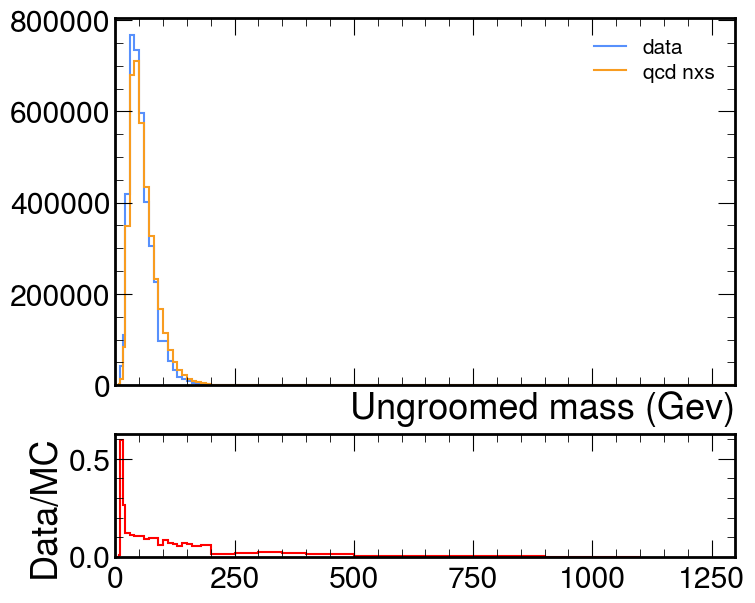

In [11]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result_noxs["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result_noxs["ptreco_mreco_u"].project("mreco").axes[0]] + [result_noxs["ptreco_mreco_u"].project('mreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").axes[0]] + [result_data["ptreco_mreco_u"].project('mreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
# hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_noxs
ax.set_xlim(0,1300)
# ax.set_yscale('log')
hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False, color='red')
# hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False)
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Ungroomed mass (Gev)")

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'Q2muFDown', 'PUSFDown', 'LuminosityUp', 'Q2muFUp', 'PUSFUp', 'L1prefiringUp', 'PDFUp', 'Q2muRUp', 'Q2muRDown', 'L1prefiringDown', 'PDFDown', 'LuminosityDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=4.85852e+08, variance=3.51896e+10)
Hist(
  StrCategory(['/JetHTdata2018'], grow

Text(1, 0, 'Pt (Gev)')

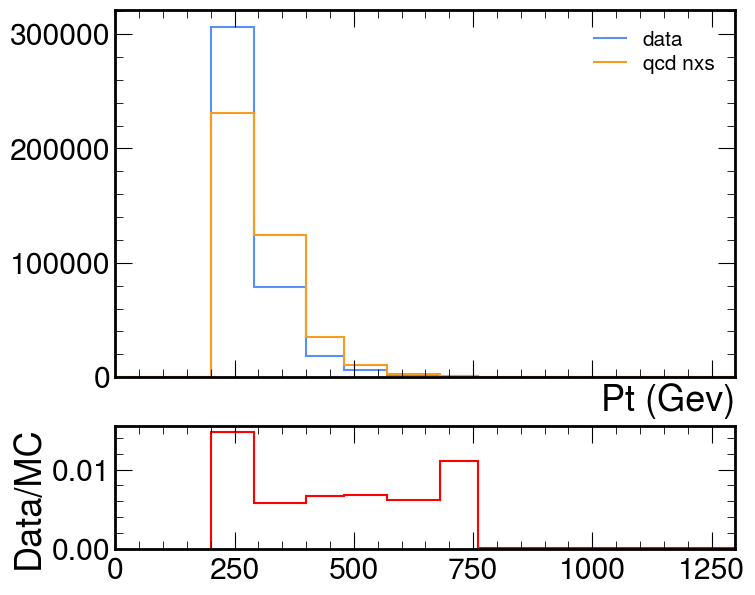

In [12]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result_noxs["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result_noxs["ptreco_mreco_u"].project("ptreco").axes[0]] + [result_noxs["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").axes[0]] + [result_data["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
# hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_noxs
ax.set_xlim(0,1300)
# ax.set_yscale('log')
hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False, color='red')
# hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False)
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Pt (Gev)")

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'Q2muFDown', 'PUSFDown', 'LuminosityUp', 'Q2muFUp', 'PUSFUp', 'L1prefiringUp', 'PDFUp', 'Q2muRUp', 'Q2muRDown', 'L1prefiringDown', 'PDFDown', 'LuminosityDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=4.85852e+08, variance=3.51896e+10)
Hist(
  StrCategory(['/JetHTdata2018'], grow

Text(1, 0, 'Pt (Gev)')

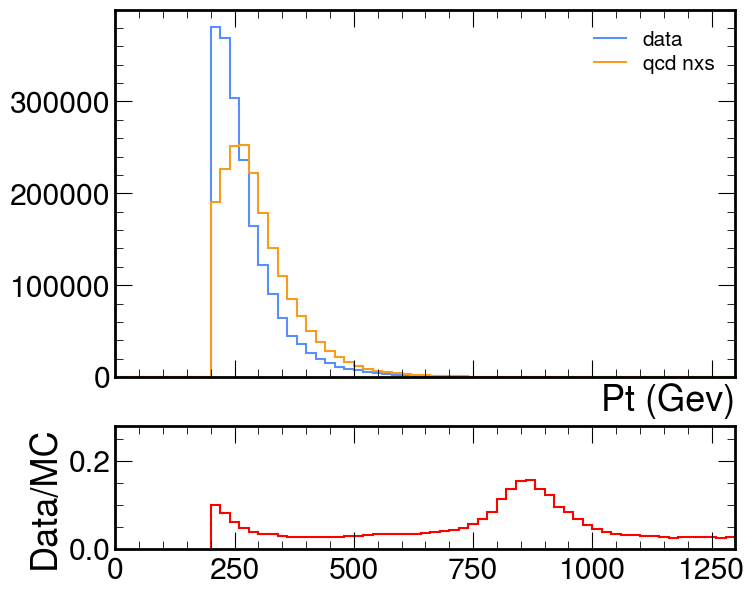

In [13]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result_noxs["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result_noxs["ptreco_mreco_fine_u"].project("pt").axes[0]] + [result_noxs["ptreco_mreco_fine_u"].project('pt').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").axes[0]] + [result_data["ptreco_mreco_fine_u"].project('pt').axes[0][-1][1]]
print(edges_data)
hist_data = result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
# hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_noxs
ax.set_xlim(0,1300)
# ax.set_yscale('log')
hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False, color='red')
# hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False)
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Pt (Gev)")

dict_keys(['misses_u', 'misses_g', 'passes_u', 'passes_g', 'fakes_u', 'fakes_g', 'weights', 'ptreco_mreco_u', 'ptreco_mreco_g', 'rho_reco_u', 'rho_reco_g', 'ptgen_mgen_u', 'ptgen_mgen_g', 'response_rho_u', 'response_rho_g', 'response_matrix_u', 'response_matrix_g', 'cutflow', 'jkflow', 'alljet_ptreco_mreco', 'btag_eta', 'mass_orig', 'sdmass_orig', 'sdmass_ak8corr', 'sdmass_ak4corr', 'HT_nocuts', 'HT_wXS', 'HT_aftercuts', 'MET_over_sumET_pt_reco', 'MET_pt_reco', 'njet_reco', 'njet_gen', 'jet_rap_reco', 'jet_rap_gen', 'jet_phi_gen', 'jet_phi_reco', 'jet_eta_phi_precuts', 'jet_eta_phi_preveto', 'jet_pt_eta_phi', 'dphi_gen', 'dphi_reco', 'asymm_gen', 'asymm_reco', 'jet_dr_gen_subjet', 'dijet_dr_reco_to_gen', 'dr_reco_to_gen_subjet', 'ptreco_mreco_fine_u', 'ptreco_mreco_fine_g', 'fakes_eta_phi', 'fakes_asymm_dphi'])
dict_keys(['misses_u', 'misses_g', 'passes_u', 'passes_g', 'fakes_u', 'fakes_g', 'weights', 'ptreco_mreco_u', 'ptreco_mreco_g', 'rho_reco_u', 'rho_reco_g', 'ptgen_mgen_u', 'ptge

Text(1, 0, 'Pt (Gev)')

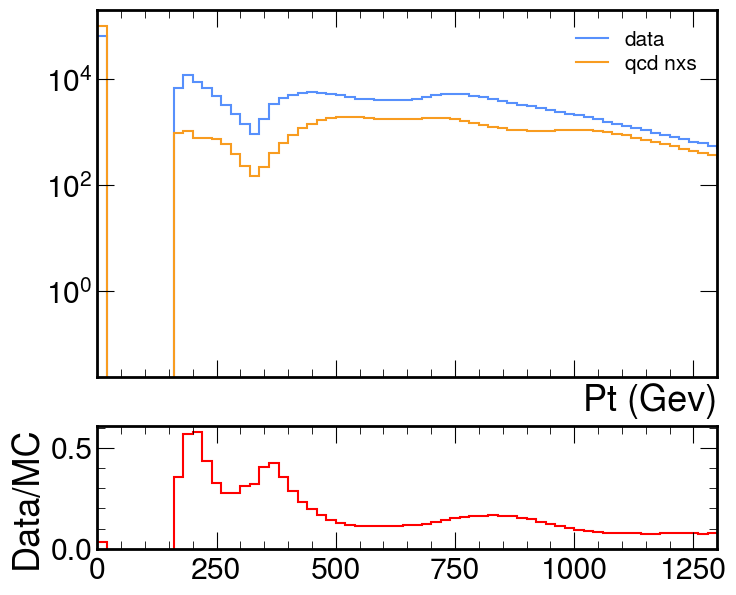

In [19]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result_noxs.keys())
print(result_data.keys())
hist_name = "HT_nocuts"
edges = [bin[0] for bin in result_noxs[hist_name].project("pt").axes[0]] + [result_noxs[hist_name].project('pt').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data[hist_name].project("pt").axes[0]] + [result_data[hist_name].project('pt').axes[0][-1][1]]
print(edges_data)
hist_data = result_data[hist_name].project("pt").values()
# hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs[hist_name].project("pt").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_noxs
ax.set_xlim(0,1300)
ax.set_yscale('log')
hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False, color='red')
# hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False)
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Pt (Gev)")